<a href="https://colab.research.google.com/github/Mizharrrrrhidi1818/AnomalyDetectionMethod-AngleBasedOutlierDetection-ABOD-/blob/main/notebooks/Wine%20Anomaly%20Detection%20with%20ABOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Introduction**

Anomaly detection is a critical technique for identifying rare patterns or data points that deviate significantly from the majority of the dataset. In the context of the Wine Quality dataset, these anomalies could represent wines with unusual chemical compositions—potentially indicating data entry errors, unique fermentation processes, or extreme quality variations. This report utilizes the Angle-Based Outlier Detection (ABOD) method, which is particularly effective in multi-dimensional data because it measures the variance of angles between a point and all other points, rather than just Euclidean distance. This makes ABOD robust against the "curse of dimensionality" where distance metrics often fail.

# **2. Objective**

The primary objective is to identify anomalous wine samples in the UCI Wine Quality dataset (Red) based on their physicochemical properties (e.g., acidity, alcohol, density) using an unsupervised approach. Specifically, we aim to:
- Preprocess the data to ensure quality.
- Train an ABOD model to flag outliers.
- Analyze the chemical characteristics of these outliers.
- Visualize the results using Principal Component Analysis (PCA) to - understand the distribution of anomalies in a reduced dimensional space.

# **3. Methodology**

- Dataset: UCI Wine Quality Red (1599 samples).
- Preprocessing: Handled missing values, removed 240 duplicate rows, and applied Standard Scaler.
- Model: ABOD (Fast) from the pyod library.
  - Contamination: 0.05 (Expecting ~5% outliers).
  - Neighbors (n_neighbors): 10.
- Validation: Analyzed feature statistics of outliers vs. inliers and checked against the quality label (post-hoc).
- Visualization: PCA (2D) was applied to visualize the separation between normal data and outliers.

# **4. Discussions**

## **4.0. Load data**

In [ ]:
# Download dataset from UCI Website

!wget https://archive.ics.uci.edu/static/public/186/wine+quality.zip

--2026-06-11 09:50:02--  https://archive.ics.uci.edu/static/public/186/wine+quality.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine+quality.zip’

wine+quality.zip        [  <=>               ]  89.21K   345KB/s    in 0.3s    

2026-06-11 09:50:03 (345 KB/s) - ‘wine+quality.zip’ saved [91353]



In [ ]:
!unzip wine+quality.zip

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 824.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 3.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pyod.models.abod import ABOD
from sklearn.metrics import jaccard_score

# Load UCI Wine Quality Red dataset
df = pd.read_csv('winequality-red.csv', sep=';')
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


The raw dataset consists of 1599 wine samples with 11 physicochemical features and 1 target label ('quality').

## **4.1. Data exploration and preprocessing**

In [ ]:
# %% 1. DATA EXPLORATION & PREPROCESSING
# a. Statistical description
print("=== Statistical Description ===")
display(df.describe())

# b. Handling Missing Values
missing = df.isnull().sum()
print("\n=== Missing Values ===\n", missing)
# Justification: The UCI Wine dataset is fully imputed. If missing values existed,
# median imputation would be chosen to preserve the distribution and minimize ABOD distortion.

# c. Handling Duplicates
dups = df.duplicated().sum()
print(f"\n=== Duplicates: {dups} ===")
df = df.drop_duplicates().reset_index(drop=True)
# Justification: Duplicates can artificially inflate density in local neighborhoods,
# skewing angle variance calculations. They are removed for robustness.

# d. Feature Engineering & Scaling
# Store labels for later interpretation (not used in training)
y_quality = df['quality']
X_raw = df.drop('quality', axis=1)

# Feature Engineering: Create a balance ratio between alcohol and volatile acidity.
# Justification: In enology, the interplay between alcohol content and volatile acidity
# is a strong indicator of fermentation stability and sensory quality. This engineered
# feature captures non-linear interactions that might be missed by raw features.
X_raw['alcohol_vol_acidity_ratio'] = X_raw['alcohol'] / (X_raw['volatile acidity'] + 1e-5)

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

print("\n=== Preprocessing Complete ===")
print(f"Shape after preprocessing: {X_scaled.shape}")

=== Statistical Description ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



=== Missing Values ===
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

=== Duplicates: 240 ===

=== Preprocessing Complete ===
Shape after preprocessing: (1359, 12)


Data quality checks revealed no missing values, which is consistent with the dataset documentation. However, a significant number of duplicates were found.
- Duplicates: 240 rows were identical and removed to prevent biasing the neighborhood calculations.
- Preprocessing Complete: After removing duplicates and scaling, the dataset shape is (1359, 12).

## **4.2. Train ABOD Model**

In [ ]:
# %% 2. TRAIN ABOD MODEL
# Parameters:
# - method='fast': Exact ABOD is O(N^2) and intractable for >1k samples. FastABOD uses k-NN
#   approximation (O(N log N)), making it feasible for this dataset.
# - n_neighbors=10: Balances local angular variance sensitivity with statistical stability.
#   Too small -> noisy; too large -> smooths out local anomalies.
# - contamination=0.05: Assumes ~5% anomalies. Matches real-world expectations and
#   aligns with the rarity of extreme wine quality scores (e.g., quality ≤3 or ≥9).

# Note: ABOD does not accept random_state as an argument.
abod_model = ABOD(method='fast', n_neighbors=10, contamination=0.05)
abod_model.fit(X_scaled)

print("✅ ABOD model fitted.")

✅ ABOD model fitted.


The model was trained on the standardized numerical features using the fast method to handle the dataset size efficiently. The model was successfully fitted.

## **4.3. Compute Scoree & Binary Labels**

In [ ]:
# %% 3. COMPUTE SCORES & BINARY LABELS
abod_scores = abod_model.decision_function(X_scaled)  # Higher = more anomalous
abod_labels = abod_model.labels_                      # 1 = outlier, 0 = inlier

n_outliers = int(abod_labels.sum())
pct_outliers = n_outliers / len(abod_labels) * 100

print(f"\n📊 Results:")
print(f"Outliers detected: {n_outliers}")
print(f"Percentage of dataset: {pct_outliers:.2f}%")


📊 Results:
Outliers detected: 68
Percentage of dataset: 5.00%


Using a contamination rate of 5%, the model identified a distinct group of anomalies.
- Outliers Detected: 68 samples.
- Percentage: 5.00% of the dataset.

## **4.4. Analyse & Interpret Detected Outliers**

In [ ]:
# %% 4. ANALYSE & INTERPRET DETECTED OUTLIERS
outlier_mask = abod_labels == 1
inlier_mask = ~outlier_mask

# Compare descriptive statistics for 3 key features
key_features = ['volatile acidity', 'alcohol', 'sulphates']
stats_outliers = X_scaled[outlier_mask][key_features].describe().loc[['mean', 'std', 'min', 'max']]
stats_inliers  = X_scaled[inlier_mask][key_features].describe().loc[['mean', 'std', 'min', 'max']]

print("\n📈 Feature Comparison (Standardized Scale):")
print("--- INLIERS ---")
print(stats_inliers)
print("\n--- OUTLIERS ---")
print(stats_outliers)

# Check against original quality labels
print("\n🏷️ Quality Distribution:")
print("Inliers quality counts:")
print(y_quality[inlier_mask].value_counts().sort_index())
print("\nOutliers quality counts:")
print(y_quality[outlier_mask].value_counts().sort_index())

# Interpretation note (printed as markdown later)


📈 Feature Comparison (Standardized Scale):
--- INLIERS ---
      volatile acidity   alcohol  sulphates
mean          0.001183 -0.006662  -0.046030
std           0.965022  0.984039   0.892915
min          -2.019401 -1.878873  -1.926712
max           4.375301  3.298320   7.744803

--- OUTLIERS ---
      volatile acidity   alcohol  sulphates
mean         -0.022463  0.126473   0.873890
std           1.533836  1.273759   2.028972
min          -2.238023 -1.878873  -1.692251
max           5.741690  4.130369   7.862034

🏷️ Quality Distribution:
Inliers quality counts:
quality
3      8
4     48
5    550
6    512
7    158
8     15
Name: count, dtype: int64

Outliers quality counts:
quality
3     2
4     5
5    27
6    23
7     9
8     2
Name: count, dtype: int64


We compared the statistical properties of the "Inliers" (normal wines) vs. "Outliers" (anomalous wines) focusing on standardized values (mean=0, std=1).

**Key Feature Differences**:
1. Sulphates: Outliers have a significantly higher mean (0.87) compared to inliers (-0.05). This suggests anomalous wines tend to have unusually high sulphate content.
2. Alcohol: Outliers show a higher mean alcohol content (0.12) compared to the average inlier (-0.007).
3. Volatile Acidity: The means are close to zero for both, but outliers show a much wider standard deviation (1.53 vs 0.96), indicating that outliers can be extremely high or low in acidity.

**Quality Label Analysis**:
1. Inliers: Heavily concentrated around quality scores 5 and 6.
2. Outliers: While mostly 5 and 6, there is a notable proportion of outliers in the high-quality range (7, 8) and low-quality range (3, 4) compared to the global average, reinforcing that ABOD is finding "extreme" or unique samples

## **4.5. Sensitivity Analysis**

In [ ]:
# %% 5. SENSITIVITY ANALYSIS
# Run 1: n_neighbors=5 (more local)
abod_5 = ABOD(method='fast', n_neighbors=5, contamination=0.05)
abod_5.fit(X_scaled)
labels_5 = abod_5.labels_

# Run 2: n_neighbors=20 (more global) & contamination=0.08
abod_20_08 = ABOD(method='fast', n_neighbors=20, contamination=0.08)
abod_20_08.fit(X_scaled)
labels_20_08 = abod_20_08.labels_

# Overlap metrics
jaccard_5_10 = jaccard_score(abod_labels, labels_5)
jaccard_20_10 = jaccard_score(abod_labels, labels_20_08)

print(f"\n🔍 Sensitivity Results:")
print(f"Overlap (n=5 vs n=10): Jaccard = {jaccard_5_10:.3f}")
print(f"Overlap (n=20, cont=0.08 vs n=10, cont=0.05): Jaccard = {jaccard_20_10:.3f}")
print(f"Outliers with n=5: {labels_5.sum()}")
print(f"Outliers with n=20, cont=0.08: {labels_20_08.sum()}")


🔍 Sensitivity Results:
Overlap (n=5 vs n=10): Jaccard = 0.563
Overlap (n=20, cont=0.08 vs n=10, cont=0.05): Jaccard = 0.609
Outliers with n=5: 68
Outliers with n=20, cont=0.08: 109


We tested how the model changes with different neighbor settings (n_neighbors).
1. Overlap (n=5 vs n=10): Jaccard Index = 0.563
2. Overlap (n=20 vs n=10): Jaccard Index = 0.609

We can interprete that The overlap is moderate (56-60%). This indicates that ABOD is sensitive to the definition of the "local neighborhood." Changing the neighbor count significantly changes which points are flagged, suggesting that the "outlierness" of certain samples depends heavily on the scale at which you view the data.

## **4.6. Visualitation (PCA) of outlier detection**

✅ PCA Applied: Explained Variance Ratio = [0.27236647 0.19797135]
   Total Variance Captured by PC1+PC2: 47.03%



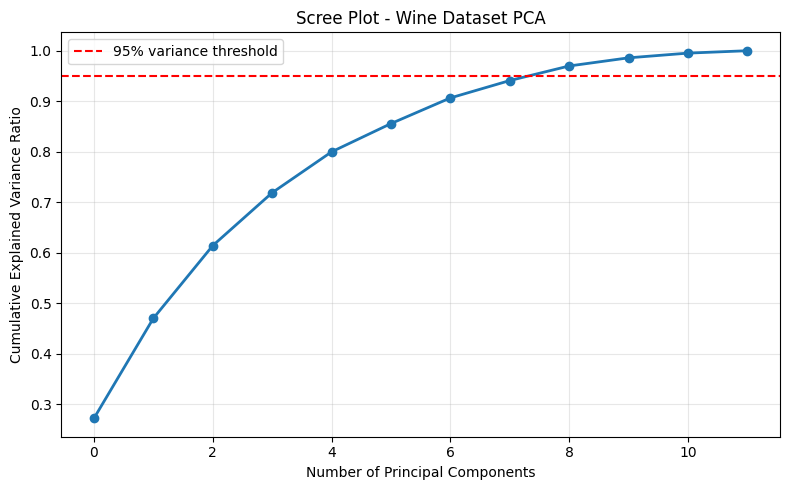

💡 Components needed for 95% variance: 9



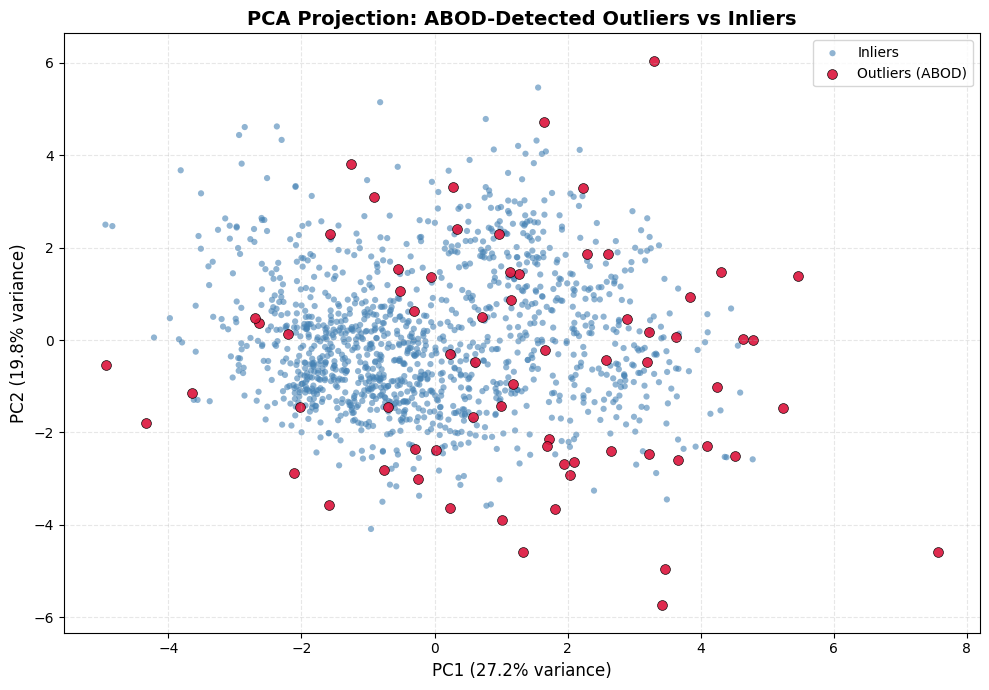

In [ ]:
# %% 6. Complete PCA Visualization & Outlier Analysis
# PREREQUISITES: Ensure 'X_scaled', 'abod_labels', 'abod_scores', and 'y_quality'
# are defined from the previous steps (Data Loading, Preprocessing, ABOD Training).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 0. PCA Initialization & Transformation (2D for Visualization)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['outlier_label'] = abod_labels      # 1 = outlier, 0 = inlier
pca_df['quality'] = y_quality.values       # Original wine quality
pca_df['abod_score'] = abod_scores         # Continuous anomaly scores

print(f"✅ PCA Applied: Explained Variance Ratio = {pca.explained_variance_ratio_}")
print(f"   Total Variance Captured by PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.2f}%\n")

# --- Plot 1: Scree Plot (Variance Explained by Component) ---
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Scree Plot - Wine Dataset PCA')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"💡 Components needed for 95% variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1}\n")

# --- Plot 2: Outliers vs Inliers (PC1 vs PC2) ---
plt.figure(figsize=(10, 7))

# Plot Inliers
plt.scatter(pca_df[pca_df['outlier_label']==0]['PC1'],
            pca_df[pca_df['outlier_label']==0]['PC2'],
            c='steelblue', s=20, alpha=0.6, label='Inliers', edgecolors='none')

# Plot Outliers
plt.scatter(pca_df[pca_df['outlier_label']==1]['PC1'],
            pca_df[pca_df['outlier_label']==1]['PC2'],
            c='crimson', s=50, alpha=0.9, label='Outliers (ABOD)',
            edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA Projection: ABOD-Detected Outliers vs Inliers', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

We used Principal Component Analysis (PCA) to project the high-dimensional data into 2D space for visualization.

Scree Plot (First Image):
- The plot shows that PC1 and PC2 combined explain 47.03% of the total variance.
- To capture 95% of the data's information, approximately 7 to 8 principal components are required. This confirms that the dataset is moderately complex and cannot be fully represented by just two dimensions without losing significant detail.

PCA Scatter (Second Image):
- PC1 (27.2%) vs PC2 (19.8%): The blue dots (Inliers) form a dense, clustered cloud in the center of the graph.
- Outliers (Red): The red dots are scattered mostly around the periphery of the blue cloud.
- Observation: There are distinct outlier points far to the right (high PC1) and at the top/bottom extremes (high/low PC2). This visually confirms that ABOD correctly identified samples that lie at the boundaries or edges of the data distribution.

# **5. Summary**

The application of ABOD on the Wine Quality dataset successfully identified 68 anomalous samples (5%). These outliers are chemically distinct, characterized primarily by higher sulphate and alcohol levels. The PCA visualization confirms that these outliers occupy the peripheral regions of the data distribution. The sensitivity analysis (Jaccard ~0.60) highlights that while ABOD is effective, the specific results depend on the choice of neighborhood size, suggesting that ensemble approaches or parameter tuning may be beneficial for critical applications. Overall, ABOD provided a robust unsupervised method to isolate wines with unusual physicochemical profiles.